<a href="https://colab.research.google.com/github/colbrydi/Scientific_Image_Understanding/blob/master/03-Binary_Morphology-pre-class-assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-Class Assignment: Binary Morphology
In this pre-class assignment we will use binary image morphology to improve our ability to do image segmentation.

### Goals for today's pre-class assignment

1. [Color Thresholding](#Color_Thresholding)
1. [Dilation and Erosion](#Dilation_and_Erosion)
1. [Other Binary Morphology functions](#Other_Binary_Morphology_Operations)
1. [Over the sholder example](#Over_the_sholder_example)

----
<a name="Color_Thresholding"></a>
# 1. Color Thresholding

The following code tries to color segment an image

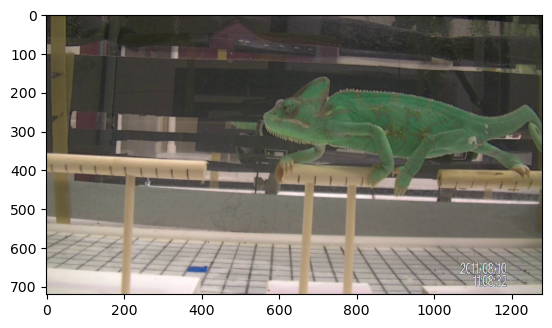

In [2]:
# The following code snippet reads any file from the internet and saves it to your local directory.

from urllib.request import urlopen, urlretrieve
import imageio.v2 as imageio
%matplotlib inline
import matplotlib.pylab as plt
import numpy as np

url = 'https://goo.gl/g4wdeF'
file = 'Chameleon.jpg'
urlretrieve(url, file)

im = imageio.imread(file)
plt.imshow(im)

In [7]:
#Use Logical operators for each RGB Color channel
r_threshold = im[:,:,0] < 100
g_threshold = im[:,:,1] > 90
b_threshold = im[:,:,2] < 100

In [8]:
#Use Logical to combine results of each channel
binary_image = np.logical_and(r_threshold,g_threshold)
binary_image = np.logical_and(binary_image,b_threshold)

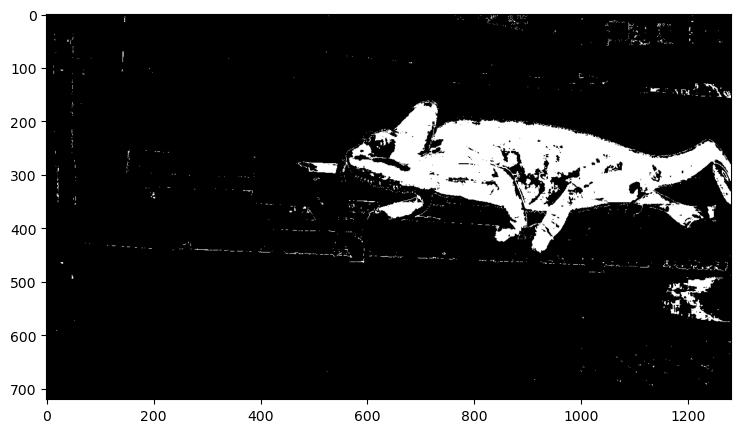

In [9]:
#display the binary image result from color segmentation
plt.figure(figsize = (10,5))
plt.imshow(binary_image, cmap='gray',vmin=0,vmax=1);

---
<a name="Dilation_and_Erosion"></a>
# 2. Dilation and Erosion
How can we make the above images look better?  We will use two "Binary Image Morphology" operators called Dilation and Erosion that can "grow" and "shrink" the "true" regions in our above image.  Watch the following video on dilation:

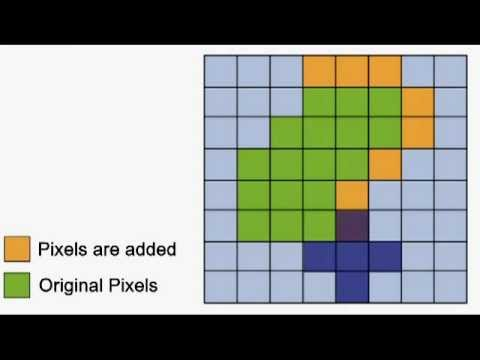

In [10]:
#Dilation
from IPython.display import YouTubeVideo
YouTubeVideo("xO3ED27rMHs",width=640,height=360)

The following python snipit in the ndimage package uses a square structure element (3x3) to dilate the image. You can change the iterations input option to increase the number of times the structure element is applied:

Text(0.5, 1.0, 'After Dilation')

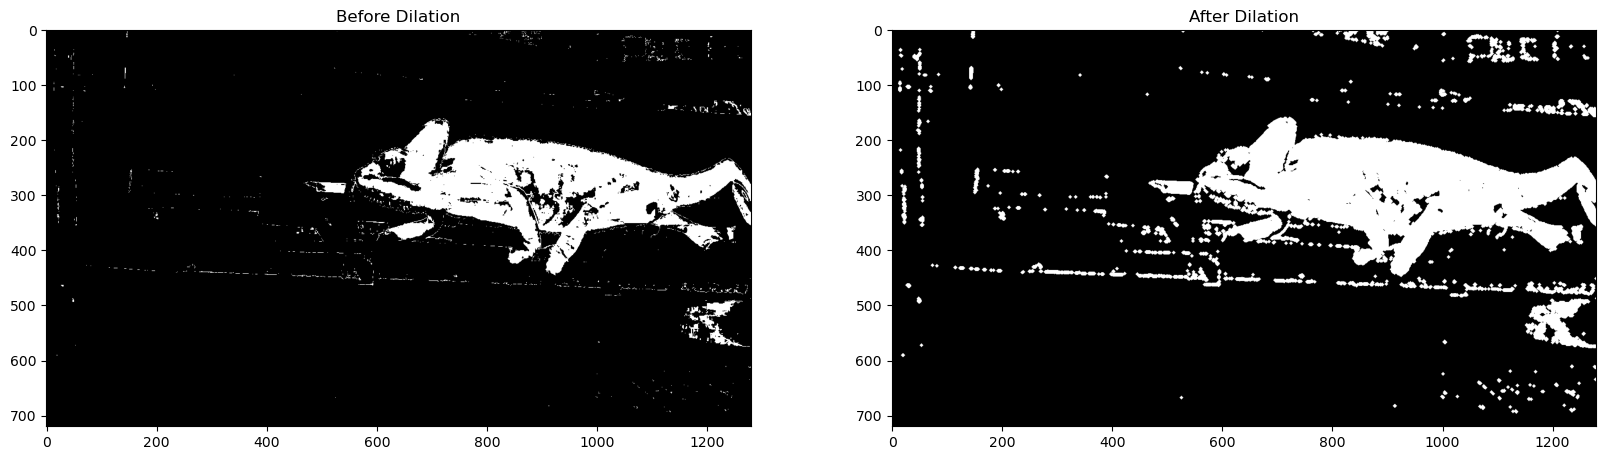

In [11]:
from scipy import ndimage

#Example of Dialation using ndimage in scipy
after_dialation = ndimage.binary_dilation(binary_image, iterations=3)
f, (ax1, ax2) = plt.subplots(1, 2,figsize=(20,10))
ax1.imshow(binary_image, cmap='gray')
ax1.set_title("Before Dilation")

ax2.imshow(after_dialation, cmap='gray')
ax2.set_title("After Dilation")

Notice how more of the chameleon is included in this expanded image

Now consider the following video on **Erosion**:

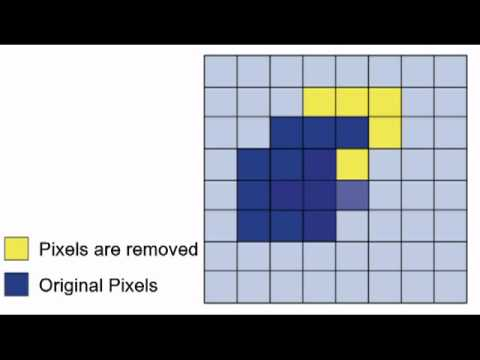

In [12]:
#Erosion
from IPython.display import YouTubeVideo
YouTubeVideo("fmyE7DiaIYQ",width=640,height=360)

The following python snipit in the ndimage package uses a square structure element (3x3) to erode the image. You can change the iterations input option to increase the number of times the structure element is applied:

Text(0.5, 1.0, 'After Erosion')

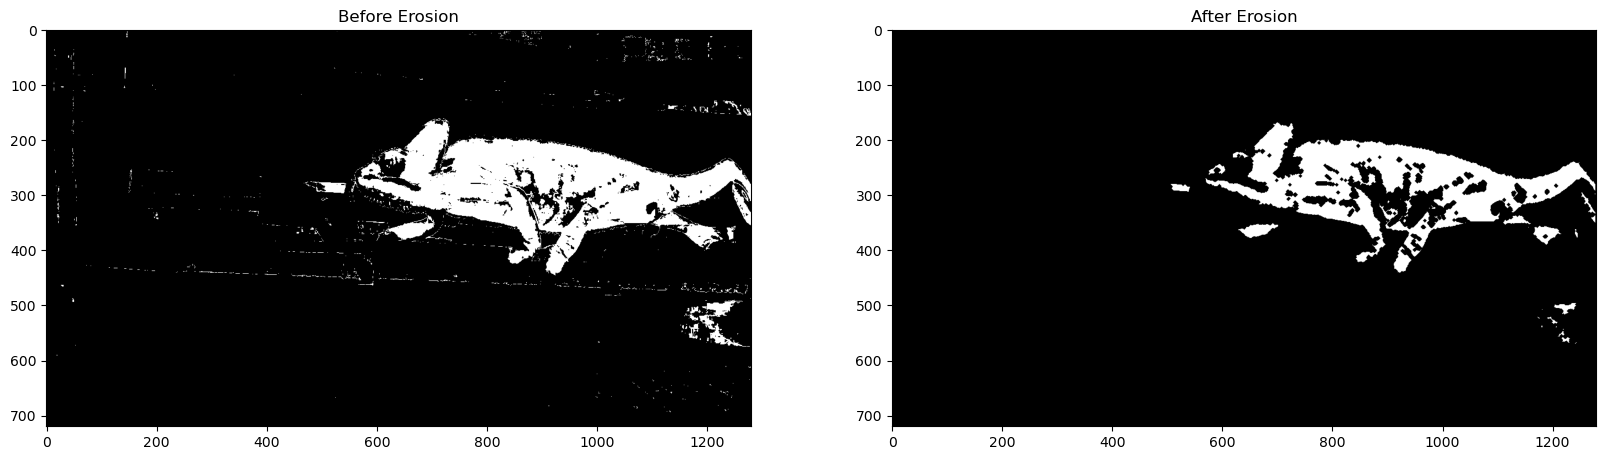

In [13]:
from scipy import ndimage

after_erosion = ndimage.binary_erosion(binary_image, iterations=3)
f, (ax1, ax2) = plt.subplots(1, 2,figsize=(20,10))
ax1.imshow(binary_image, cmap='gray')
ax1.set_title("Before Erosion")

ax2.imshow(after_erosion, cmap='gray')
ax2.set_title("After Erosion")

Notice that the small pixel "noise" has been removed from the image.  

&#9989; **Do This:** Think about how you could combine erosion and dilation to do a better job at segmentation of the chameleon.  The goal is to find a combination and sequence of dilation and erosion that only provides the entire chameleon and eliminates all of the background.

Modify the following code to try to best segment out the chameleon.  Feel free to change the order of the algorithms or add your own logic:

In [15]:
bw1 = ndimage.binary_erosion(binary_image, iterations=5)
bw2 = ndimage.binary_dilation(bw1, iterations=7)

Text(0.5, 1.0, 'Erosion and then Dilagion')

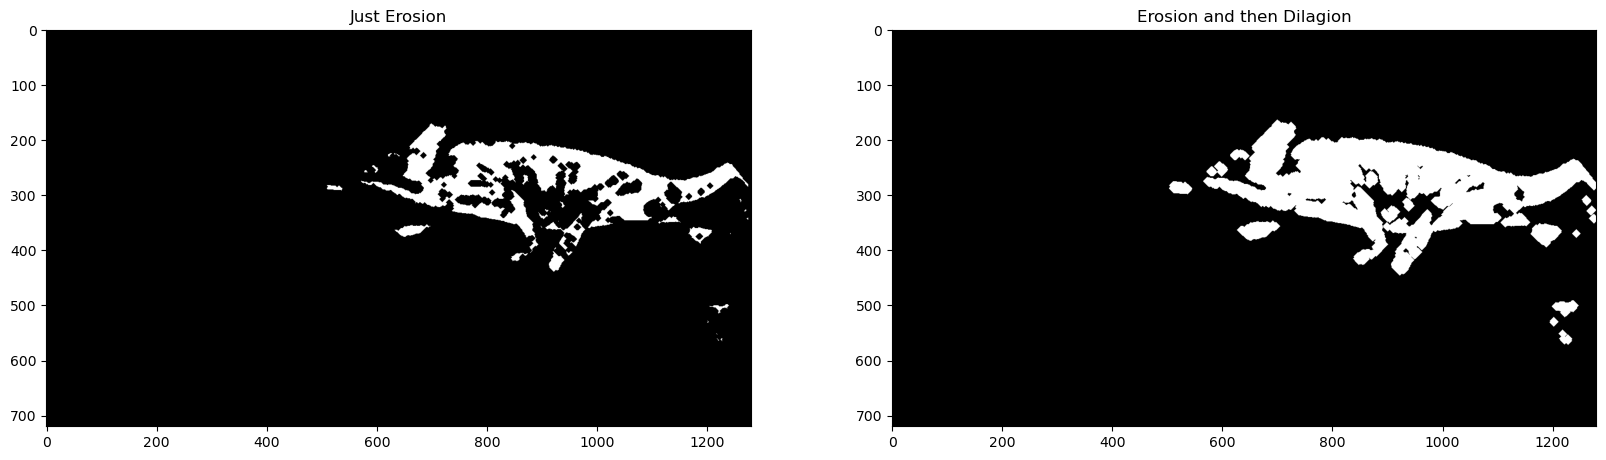

In [16]:
f, (ax1, ax2) = plt.subplots(1, 2,figsize=(20,10))
im2 = im.copy()
ax1.imshow(bw1, cmap='gray')
ax1.set_title("Just Erosion")

im2 = im.copy()
ax2.imshow(bw2,cmap='gray')
ax2.set_title("Erosion and then Dilagion")

----
<a name="Other_Binary_Morphology_Operations"></a>
# 3.  Other Binary Morphology Operations

Both **Dilation** and **Erosion** come from a class of algorithms called "binary morphology".  These algorithms all take binary images as inputs and return modified binary images as outputs.  Because the inputs are the same as the outputs you can string them together. 

**&#9989;  DO THIS** review the functions available in the ```ndimage``` python class related to morphology:

https://docs.scipy.org/doc/scipy/reference/ndimage.html

**Question:** Which of these functions sound like they may be useful to help better segment the chameleon and why? 

<font size=8 color="#009600">&#9998;</font> Do This - Erase the contents of this cell and replace it with your answer to the above question!  (double-click on this text to edit this cell, and hit shift+enter to save the text)

The following operation uses one of the other morphology functions.  We can use the function as an "index" into the original image.  Notice the lines in the following code that remove the background from the image by setting all values corresponding to "false" in the binary images equal to zero.

Text(0.5, 1.0, 'Segmented Image')

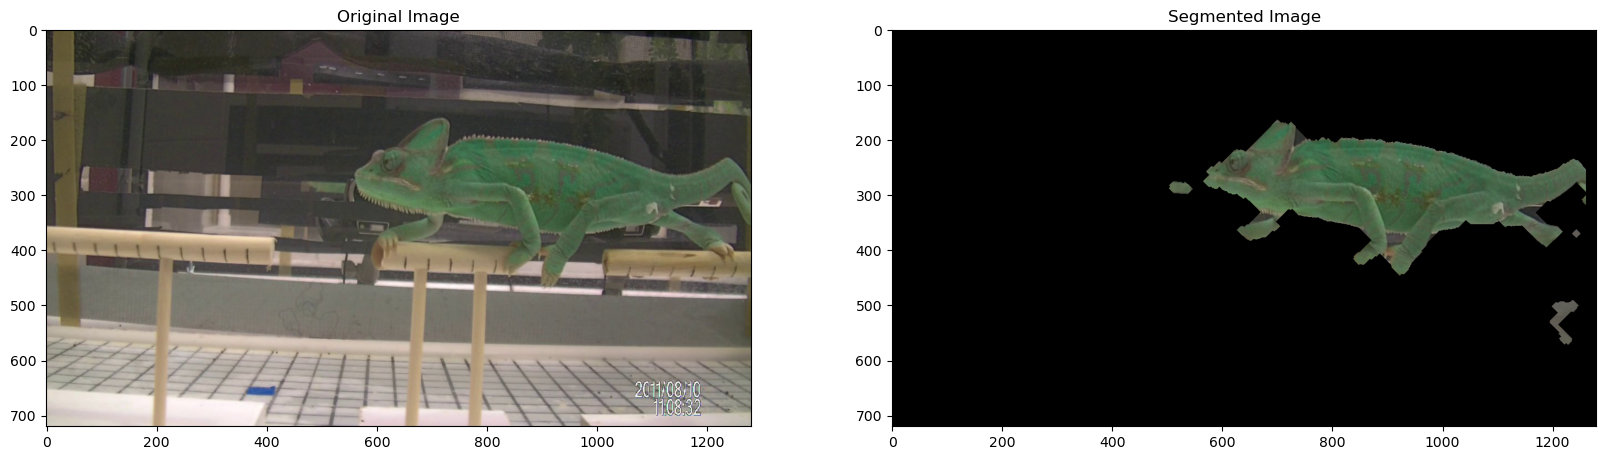

In [17]:
bw1 = ndimage.binary_erosion(binary_image, iterations=5)
bw2 = ndimage.binary_dilation(bw1, iterations=7)
bw3 = ndimage.binary_closing(bw2, iterations=20)

f, (ax1, ax2) = plt.subplots(1, 2,figsize=(20,10))
ax1.imshow(im)
ax1.set_title("Original Image")

im2 = im.copy()
im2[bw3==False,:] = 0 #Remove Background
ax2.imshow(im2)
ax2.set_title("Segmented Image")

----
<a name="Over_the_sholder_example"></a>
# 4. Over the shoulder example

This is a LONG example video (~26 minutes) of using image morphology in a real world programming problem (this is more scientific visualization rather than scientific image analysis). This is "over the solder" instruction where you can see everything I did including my debugging technique and troubleshooting.  Some students find this kind of instruction very helpful, others find it tedious and annoying.  

I will not ask any question in this notebook so feel free to at double speed or skip though based on your interest and time. The important part is my introduction to "object labeling" which I start talking about approximately 11 minutes and 45 seconds into the video.  We will use this concept/function in class.

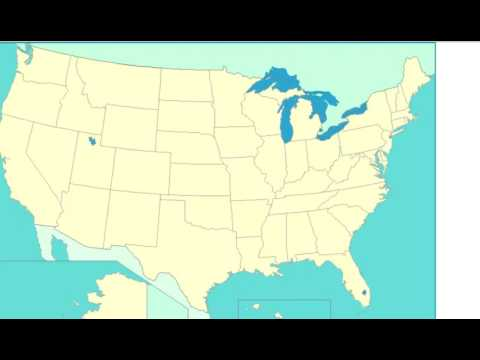

In [18]:
from IPython.display import YouTubeVideo
YouTubeVideo("3KRZtVZfn-Q",width=640,height=360)

Here is most of the code from the video for your reference. Make sure you download the image which can be found here:

http://www.yourchildlearns.com/online-atlas/images/map-of-united-states-2.gif

In [19]:
#The following code snip-it downloads a file from internet and saves it to your local directory.
from urllib.request import urlopen, urlretrieve

url='http://www.yourchildlearns.com/online-atlas/images/map-of-united-states-2.gif'
file = './map-of-united-states.gif'
urlretrieve(url, file);

In [20]:
%matplotlib inline
import numpy as np
from scipy import ndimage
import matplotlib.pylab as plt
from PIL import Image

img = Image.open(file)

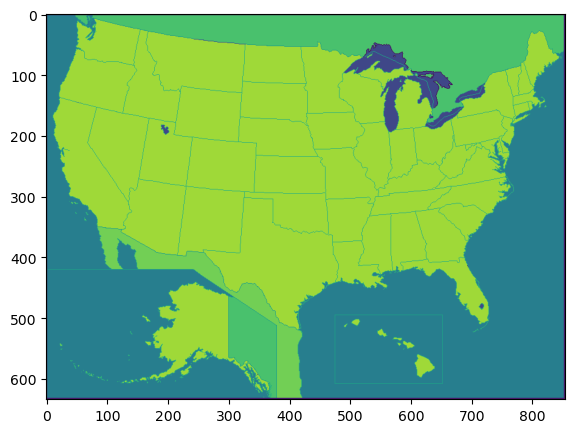

In [21]:
np_img = np.asarray(img)
plt.figure(figsize = (10,5))
plt.imshow(np_img)

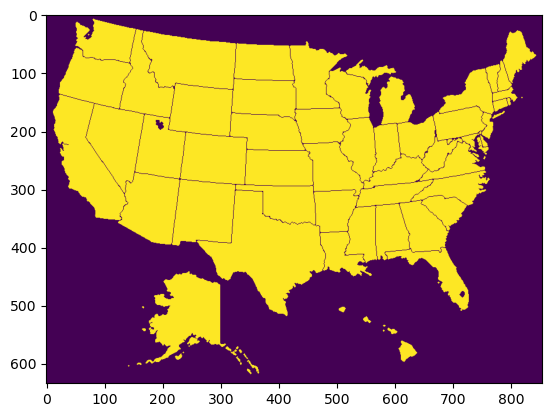

In [22]:
bw = np_img > 12 
bw = ndimage.binary_erosion(bw, iterations=1)
bw = ndimage.binary_dilation(bw)
plt.imshow(bw)

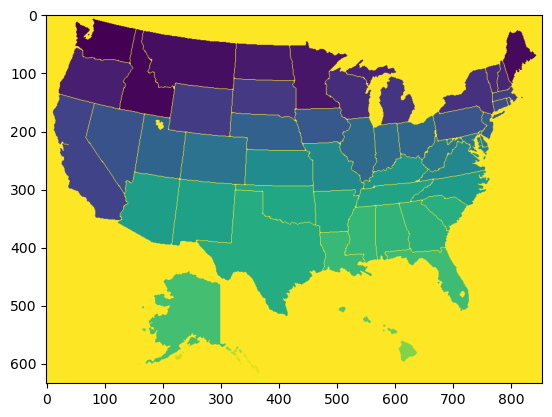

In [24]:
lab, num_features = ndimage.label(bw)
lab[lab == 0] = np.max(lab)
plt.imshow(lab)

----
Written by Dr. Dirk Colbry, Michigan State University
<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

----